In [141]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from numba import njit, prange
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from IPython.display import display, HTML
from scipy.interpolate import RegularGridInterpolator
import time
import pandas as pd
from copy import deepcopy
import seaborn as sns
from numba import set_num_threads
from itertools import product
from tqdm import tqdm
from collections import defaultdict
import copy

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

set_num_threads(14)  # Ajusta al nº de núcleos que quieras

# 🌀 Case Study: 2D Shear-Layer Vortex Dynamics (Ground Truth Simulation)

In this notebook we investigate a canonical unsteady **2D shear-layer flow**, a widely used benchmark in fluid mechanics for studying **vortex roll-up, nonlinear convection, and instability growth**. This configuration provides a rich yet computationally accessible environment for exploring **Reduced-Order Models (ROMs)** and several **Data Assimilation (DA)** strategies.

---

## 📘 Governing Equations (Vorticity–Streamfunction Formulation)

We simulate the 2D incompressible Navier–Stokes equations using:

**Vorticity definition**
\[
\omega = \partial_x v - \partial_y u
\]

**Poisson equation for streamfunction**
\[
\nabla^2 \psi = -\omega
\]

**Velocity reconstruction**
\[
u = \frac{\partial \psi}{\partial y}, \qquad 
v = -\frac{\partial \psi}{\partial x}
\]

**Vorticity transport**
\[
\frac{\partial \omega}{\partial t}
+ u \frac{\partial \omega}{\partial x}
+ v \frac{\partial \omega}{\partial y}
= \nu \nabla^2 \omega
\]

This formulation ensures incompressibility by construction.

---

## 🌬 Flow Configuration

- **Domain:** \( x \in [0,4],\ y \in [-1,1] \)  
- **Grid:** uniform Cartesian mesh  
- **Initial condition:** a hyperbolic-tangent mixing layer
  \[
  u(x,y,0) = \tanh\!\left(\frac{y}{\delta}\right), \qquad v=0
  \]
- **Perturbation:** small transverse velocity noise to trigger Kelvin–Helmholtz roll-up  
- **BCs:** periodic in \(x\), free-slip in \(y\)  
- **Physics:** moderate Reynolds number, producing coherent vortices  

This setup leads to the classical *Kelvin–Helmholtz instability*, vortex roll-up, pairing, and downstream convection—ideal features for ROM and DA methods.

---

## 🎯 Purpose of This Simulation

The goal is to generate a high-fidelity **ground truth** solution that will be used to:

1. Build a **POD-based Reduced-Order Model (ROM)**  
2. Create synthetic sensors (velocity and/or pressure)  
3. Apply and compare four DA methods:
   - **Nudging**
   - **Kalman Filter**
   - **Ensemble Kalman Filter (EnKF)**
   - **4D-Var**

Students will be able to **modify sensor density, noise levels, nudging gains, covariance matrices, and ensemble sizes**, observing how each DA method impacts the reconstruction accuracy.

---


In [142]:

np.random.seed(1)

# -----------------------------
# Domain
# -----------------------------
Nx, Ny = 128, 64
Lx, Ly = 4.0, 2.0
x = np.linspace(0.0, Lx, Nx, endpoint=False)
y = np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)
Xg, Yg = np.meshgrid(x, y, indexing="ij")

dx = Lx / Nx
dy = Ly / Ny

# -----------------------------
# Time
# -----------------------------
dt = 0.01
n_snaps = 300              # number of snapshots
times = np.arange(n_snaps) * dt

# -----------------------------
# Wake parameters (synthetic)
# -----------------------------
U_inf = 1.0                # uniform flow speed
rho = 1.0                  # density (for pressure)
Gamma = 2.0                # circulation magnitude of vortices
sigma = 0.1                # vortex core size
epsilon = 0.02             # small core radius to avoid singularity

# von Kármán street geometry
lambda_x = 0.4             # streamwise spacing between vortices
y0 = 0.3                   # transverse offset of the street

# number of vortices upstream/downstream to include in the sum
n_vortices_upstream = 3
n_vortices_downstream = 8


## Snapshot generation

In [143]:
def cylinder_wake_snapshot(t):
    """
    Synthetic cylinder wake at time t:
    uniform flow + von Kármán street of Gaussian vortices.
    Returns u, v, p arrays of shape (Nx, Ny).
    """
    u = U_inf * np.ones_like(Xg)
    v = np.zeros_like(Xg)

    # posición de "cilindro" virtual
    x_cyl = 1.0

    # construimos una fila de vórtices aguas abajo y algunos aguas arriba
    for n in range(-n_vortices_upstream, n_vortices_downstream):
        # posición central en x de este par de vórtices
        x0 = x_cyl + n * lambda_x + U_inf * t   # convectan con U_inf

        # hacemos la posición periódica en x (para no perderlos del dominio)
        x0_mod = ((x0 - 0.0) % Lx) + 0.0

        # dos vórtices simétricos: uno en +y0, otro en -y0
        for sign, y_center in [(+1, y0), (-1, -y0)]:
            xc = x0_mod
            yc = y_center
            Gamma_eff = sign * Gamma

            # distancia al centro del vórtice
            dxv = Xg - xc
            dyv = Yg - yc
            r2 = dxv**2 + dyv**2 + epsilon**2

            # campo de velocidad inducido por un vórtice tipo Lamb-Oseen (simplificado)
            u_ind = -Gamma_eff / (2.0 * np.pi) * dyv / r2 * np.exp(-r2/(2*sigma**2))
            v_ind =  Gamma_eff / (2.0 * np.pi) * dxv / r2 * np.exp(-r2/(2*sigma**2))

            u += u_ind
            v += v_ind

    # presión "dinámica" relativa
    q = 0.5 * rho * (u**2 + v**2)
    p = -q + np.mean(q)   # centramos

    return u, v, p


In [144]:
snapshots = []
for k, t in enumerate(times):
    u, v, p = cylinder_wake_snapshot(t)
    snapshot_vec = np.concatenate([u.flatten(), v.flatten(), p.flatten()])
    snapshots.append(snapshot_vec)
    if k % 50 == 0:
        print(f"Generated snapshot {k}/{n_snaps}")

snapshots = np.array(snapshots)  # shape (n_snaps, 3*Nx*Ny)
print("snapshots shape:", snapshots.shape)


Generated snapshot 0/300
Generated snapshot 50/300
Generated snapshot 100/300
Generated snapshot 150/300
Generated snapshot 200/300
Generated snapshot 250/300
snapshots shape: (300, 24576)


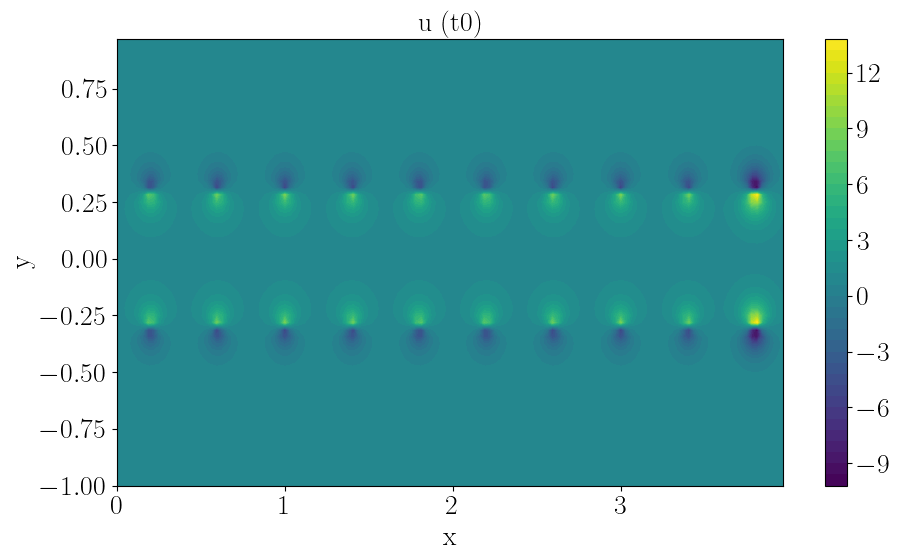

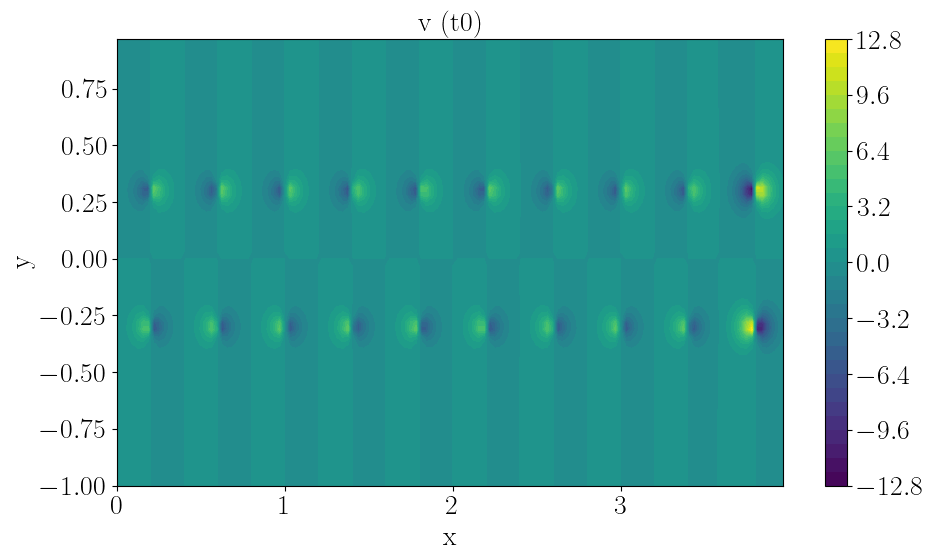

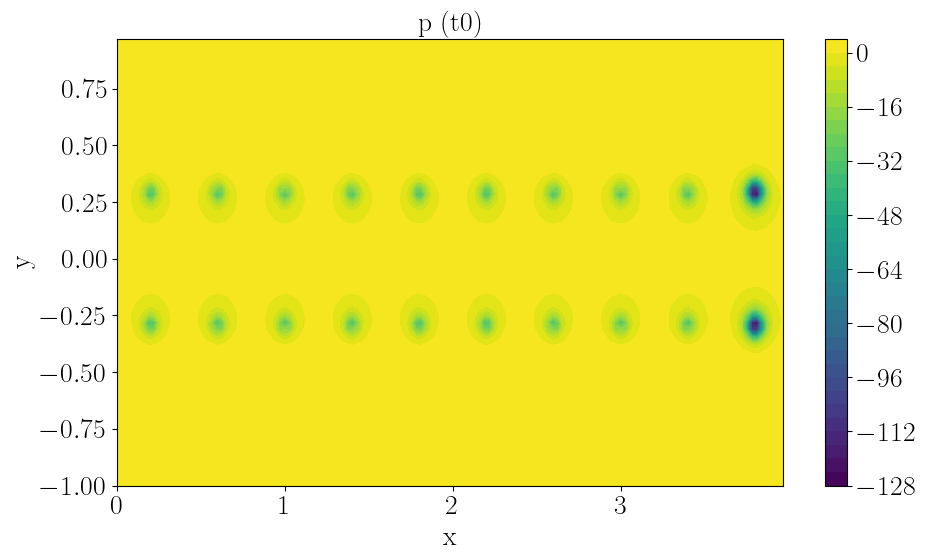

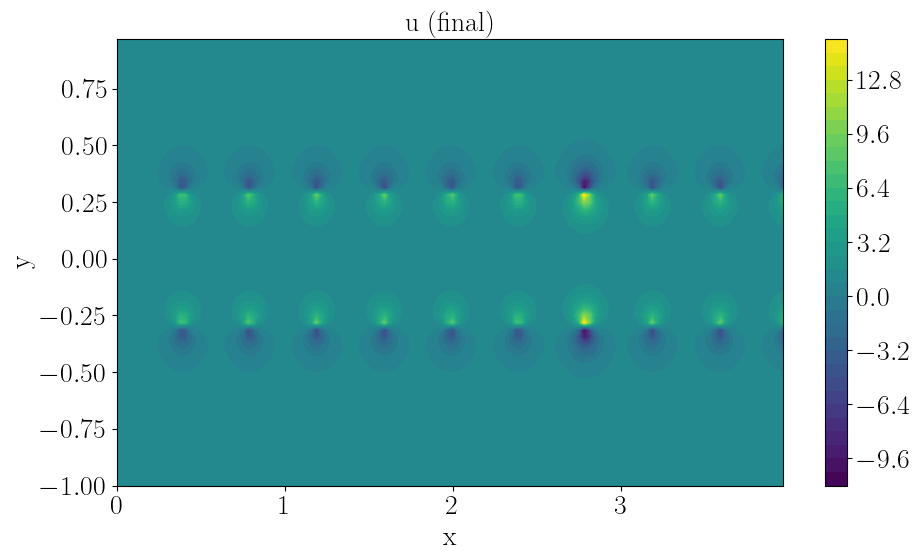

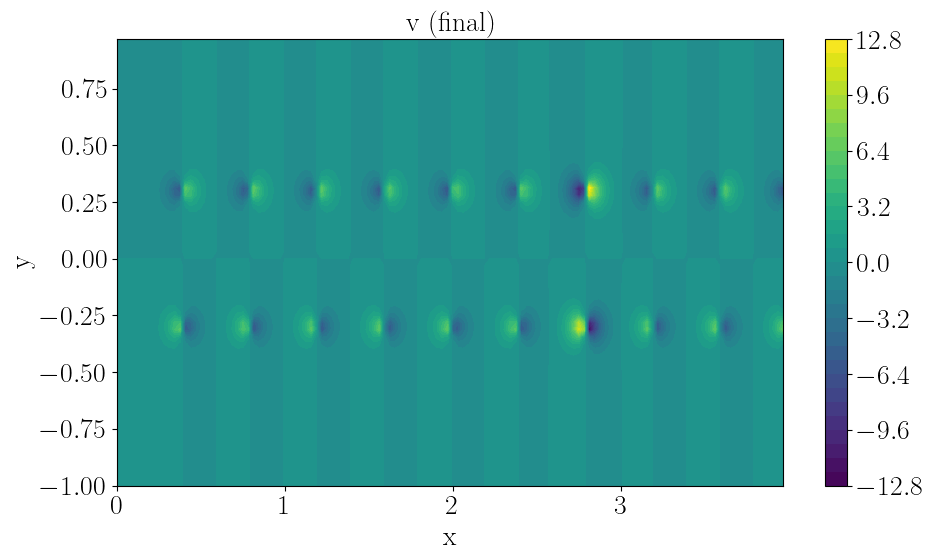

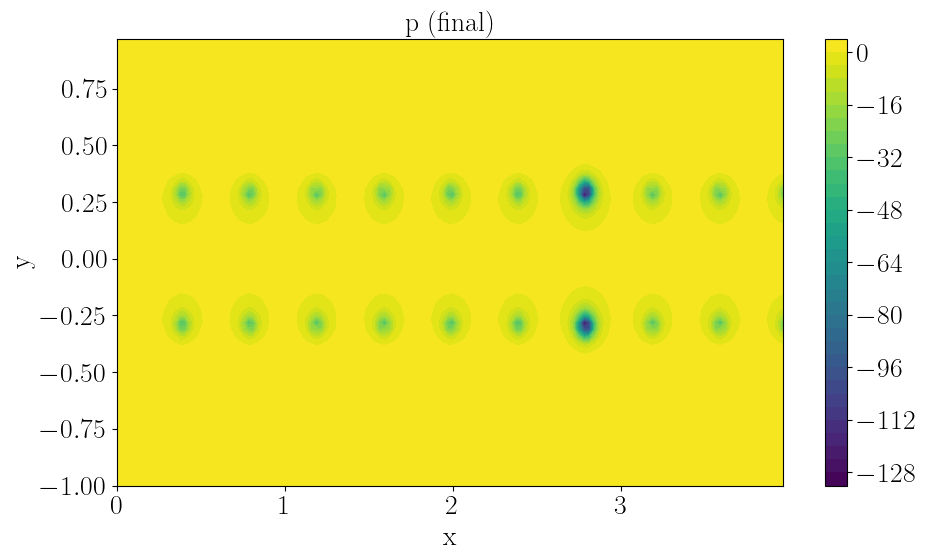

In [145]:
n_state = Nx * Ny

def plot_field(field_flat, title=""):
    field = field_flat.reshape(Nx, Ny)
    plt.figure(figsize=(10,6))
    plt.contourf(Xg, Yg, field, levels=40)
    plt.colorbar()
    plt.title(title)
    plt.xlabel("x"); plt.ylabel("y")
    plt.tight_layout()
    plt.show()

# primer snapshot
u0 = snapshots[0, 0*n_state:1*n_state]
v0 = snapshots[0, 1*n_state:2*n_state]
p0 = snapshots[0, 2*n_state:3*n_state]

plot_field(u0, "u (t0)")
plot_field(v0, "v (t0)")
plot_field(p0, "p (t0)")

# último snapshot
u_last = snapshots[-1, 0*n_state:1*n_state]
v_last = snapshots[-1, 1*n_state:2*n_state]
p_last = snapshots[-1, 2*n_state:3*n_state]

plot_field(u_last, "u (final)")
plot_field(v_last, "v (final)")
plot_field(p_last, "p (final)")


In [146]:
def plot_streamlines(u, v, title="Streamlines"):
    """
    u, v: arrays (Nx, Ny)
    """
    plt.figure(figsize=(10,6))
    speed = np.sqrt(u**2 + v**2)
    
    # fondo con magnitud de la velocidad (opcional, queda bien)
    plt.contourf(Xg, Yg, speed, levels=40)
    plt.colorbar(label="|u|")

    # líneas de corriente
    plt.streamplot(
        x, y, u.T, v.T,      # ojo: streamplot usa (x,y) 1D y campos con shape (Ny, Nx)
        density=1.2,
        linewidth=1,
        arrowsize=1.0,
        color="k"
    )

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()


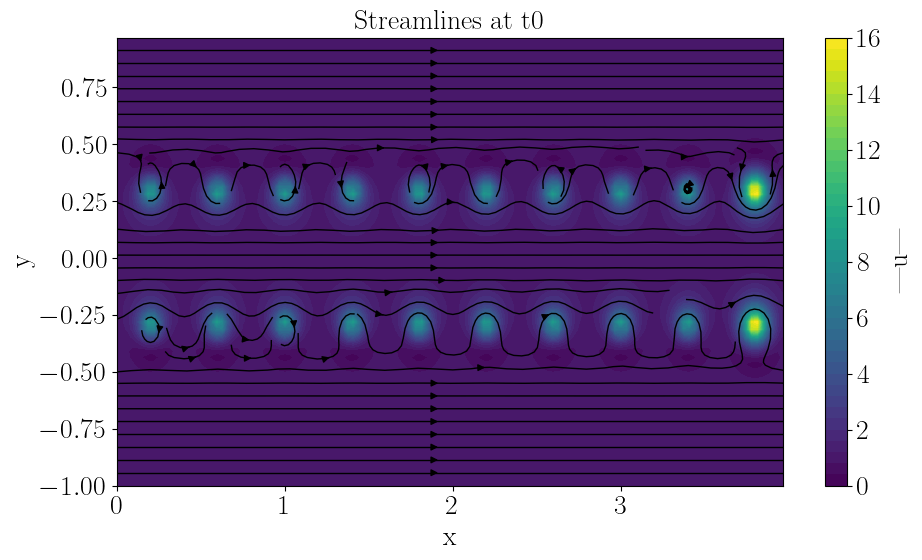

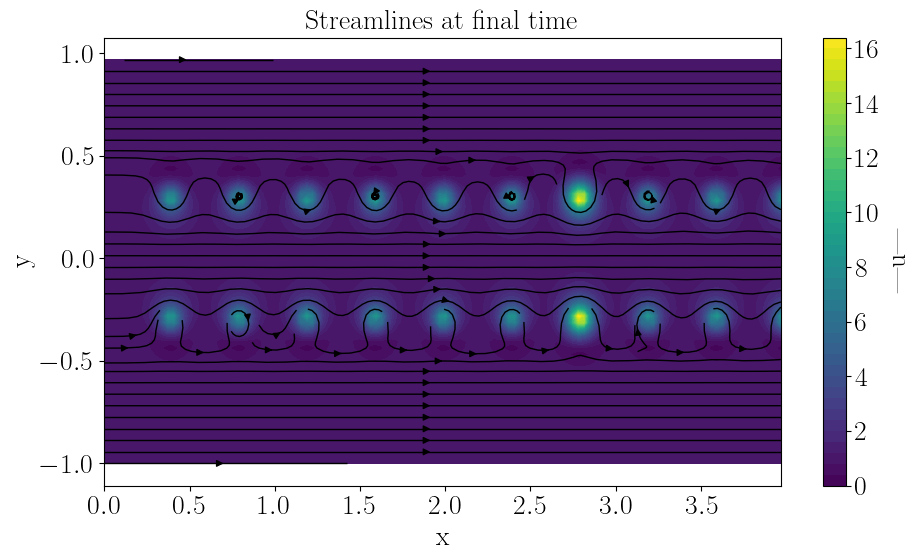

In [147]:
# primer snapshot
u0 = snapshots[0, 0*n_state:1*n_state].reshape(Nx, Ny)
v0 = snapshots[0, 1*n_state:2*n_state].reshape(Nx, Ny)

plot_streamlines(u0, v0, title="Streamlines at t0")

# último snapshot
u_last = snapshots[-1, 0*n_state:1*n_state].reshape(Nx, Ny)
v_last = snapshots[-1, 1*n_state:2*n_state].reshape(Nx, Ny)

plot_streamlines(u_last, v_last, title="Streamlines at final time")


In [148]:
# ===============================
# 1) Snapshot normalization
# ===============================

def normalize_snapshots(S, subtract_mean=True, scale_std=True):
    """
    Normalize snapshot matrix for POD/ROM/DA.

    Parameters
    ----------
    S : array (n_state, n_snapshots)
        Raw snapshot matrix.
    subtract_mean : bool
        Remove temporal mean field.
    scale_std : bool
        Scale each state variable by its global standard deviation.

    Returns
    -------
    S_norm : normalized snapshots
    mean_field : temporal mean (for reconstruction)
    std_field : standard deviation (for reconstruction)
    """

    # Compute statistics
    mean_field = np.mean(S, axis=1, keepdims=True) if subtract_mean else np.zeros_like(S[:, :1])
    S_centered = S - mean_field

    std_field = np.std(S_centered, axis=1, keepdims=True) if scale_std else np.ones_like(S[:, :1])
    
    # Avoid division by zero
    std_field[std_field < 1e-12] = 1.0

    S_norm = S_centered / std_field

    print("Snapshot matrix shape:", S.shape)
    print("Mean field removed:", subtract_mean)
    print("Standard deviation scaling:", scale_std)

    return S_norm, mean_field, std_field


# -------------------------------------
# Example usage on collected snapshots:
# -------------------------------------
S = snapshots.transpose()       # ensure shape = (n_state, n_snapshots)
S_norm, S_mean, S_std = normalize_snapshots(S)

print("Normalized snapshot shape:", S_norm.shape)


Snapshot matrix shape: (24576, 300)
Mean field removed: True
Standard deviation scaling: True
Normalized snapshot shape: (24576, 300)


## 🧠 Proper Orthogonal Decomposition (POD)

We now compute a POD basis from the normalized ground-truth snapshots.  
POD extracts the most energetic coherent structures of the flow:

\[
S_{\text{norm}} = \Phi \Sigma V^T
\]

where:

- \( \Phi \in \mathbb{R}^{n_{\text{state}} \times r} \) are the POD modes,
- \( \Sigma \) contains singular values,
- \( V \) contains temporal coefficients.

POD energy is used to decide how many modes are needed for a good ROM approximation:

\[
E(r) = \frac{\sum_{i=1}^r \sigma_i^2}{\sum_{i=1}^{N} \sigma_i^2}
\]

We typically target **99%–99.9% energy**, but students can experiment with the truncation level.


In [149]:
# ======================================
# 2) POD decomposition using SVD
# ======================================

def compute_POD(S_norm):
    """
    Compute POD basis using economy SVD.

    Parameters
    ----------
    S_norm : array (n_state, n_snapshots)
        Normalized snapshot matrix.

    Returns
    -------
    Phi : POD modes (n_state, r)
    Sigma : singular values
    Vt : right singular vectors
    """

    print("[INFO] Performing SVD…")
    U, Sigma, Vt = np.linalg.svd(S_norm, full_matrices=False)
    print("[INFO] SVD done.")
    print(" - U shape:", U.shape)
    print(" - Sigma shape:", Sigma.shape)
    print(" - Vt shape:", Vt.shape)

    return U, Sigma, Vt


# Run POD
Phi_full, Sigma, Vt = compute_POD(S_norm)

# POD energy
energy = np.cumsum(Sigma**2) / np.sum(Sigma**2)


[INFO] Performing SVD…
[INFO] SVD done.
 - U shape: (24576, 300)
 - Sigma shape: (300,)
 - Vt shape: (300, 300)


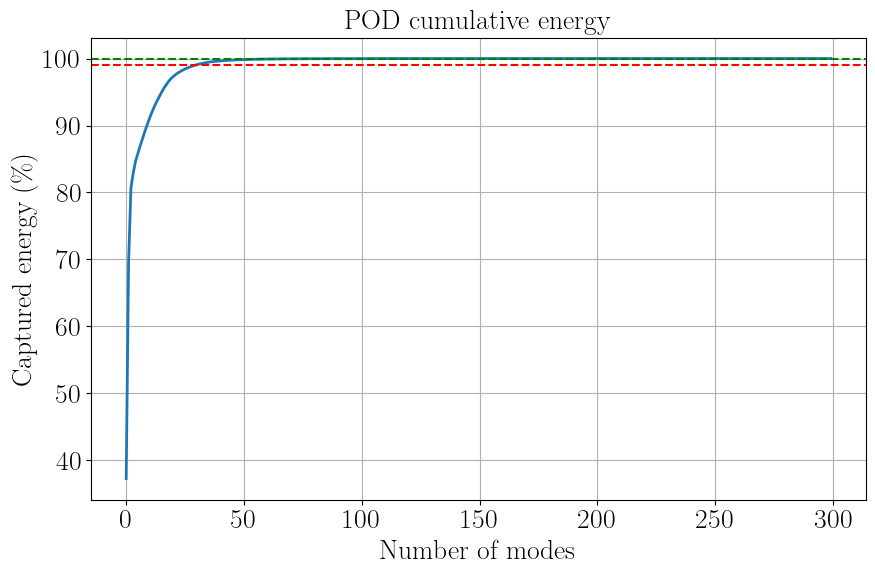

In [152]:
# ============================
# Plot POD cumulative energy
# ============================

plt.figure(figsize=(10,6))
plt.plot(energy*100, linewidth=2)
plt.axhline(99, color='r', linestyle='--')
plt.axhline(99.9, color='g', linestyle='--')

plt.xlabel("Number of modes")
plt.ylabel(r"Captured energy ($\%$)")
plt.title("POD cumulative energy")
plt.grid(True)

plt.show()
